# Vendor Performance Analysis
This notebook analyzes vendor performace using the data from the gold.vendor_performance table in PostgreSql.

 Configure Project Path 

this step add the source directory (02_src) to the Python path so custom module can be imported inside the notebook.

In [94]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent/"02_src"))

In [95]:
from db import get_engine
engine = get_engine()

In [96]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from scipy.stats import ttest_ind
from scipy.stats import stats

In [97]:
df = pd.read_sql("select * from gold.vendor_performance", engine)
df.head()

,vendor_number,vendor_name,brand,description,actual_price,avg_purchase_price,total_purchase_qty,total_sales_qty,total_purchase_amount,total_sales_amount,excise_tax,freight_cost,price_discount,gross_profit,profit_margin,sell_through_rate
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,26.27,145080,142049.0,3811251.60,5101919.51,260999.20,19325.15,10.72,1290667.91,25.30,97.91
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,23.19,164038,160247.0,3804041.22,4819073.49,294438.66,19787.63,5.80,1015032.27,21.06,97.69
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,18.24,187407,187140.0,3418303.68,4538120.60,343854.07,17539.25,6.75,1119816.92,24.68,99.86
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,16.17,201682,200412.0,3261197.94,4475972.88,368242.80,16448.90,6.82,1214774.94,27.14,99.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,21.89,138109,135838.0,3023206.01,4223107.62,249587.83,15248.51,8.10,1199901.61,28.41,98.36


In [98]:
df.shape

(10692, 16)

In [99]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_number,10692.0,10650.649458,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
brand,10692.0,18039.228769,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
actual_price,10689.0,35.653537,148.265650,0.99,10.9900,15.990,28.9900,7499.99
avg_purchase_price,10692.0,24.385303,109.269375,0.36,6.8400,10.455,19.4825,5681.81
total_purchase_qty,10692.0,3140.886831,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
total_sales_qty,10514.0,3129.573521,11037.803031,1.00,36.0000,280.000,1985.0000,334939.00
total_purchase_amount,10692.0,30106.693372,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60
total_sales_amount,10514.0,42954.173834,168977.755843,1.98,809.8200,5599.700,29524.2500,5101919.51
excise_tax,10514.0,1804.255062,11065.658551,0.06,5.3825,50.425,436.7300,368242.80
freight_cost,10692.0,153.430075,626.756009,0.00,2.3100,18.740,106.2425,19787.63


In [100]:
df.isnull().sum()

vendor_number              0
vendor_name                0
brand                      0
description                0
actual_price               3
avg_purchase_price         0
total_purchase_qty         0
total_sales_qty          178
total_purchase_amount      0
total_sales_amount       178
excise_tax               178
freight_cost               0
price_discount             3
gross_profit             178
profit_margin            178
sell_through_rate        178
dtype: int64

In [101]:
df.fillna(0, inplace=True)

,vendor_number,vendor_name,brand,description,actual_price,avg_purchase_price,total_purchase_qty,total_sales_qty,total_purchase_amount,total_sales_amount,excise_tax,freight_cost,price_discount,gross_profit,profit_margin,sell_through_rate
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,36.99,26.27,145080,142049.0,3811251.60,5101919.51,260999.20,19325.15,10.72,1290667.91,25.30,97.91
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,28.99,23.19,164038,160247.0,3804041.22,4819073.49,294438.66,19787.63,5.80,1015032.27,21.06,97.69
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,24.99,18.24,187407,187140.0,3418303.68,4538120.60,343854.07,17539.25,6.75,1119816.92,24.68,99.86
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,22.99,16.17,201682,200412.0,3261197.94,4475972.88,368242.80,16448.90,6.82,1214774.94,27.14,99.37
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,29.99,21.89,138109,135838.0,3023206.01,4223107.62,249587.83,15248.51,8.10,1199901.61,28.41,98.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10687,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,4.99,1.32,2,5.0,2.64,15.95,0.55,0.01,3.67,13.31,83.45,250.00
10688,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.00,0.39,6,134.0,2.34,65.66,7.04,0.01,0.00,63.32,96.44,2233.33
10689,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.99,0.74,2,2.0,1.48,1.98,0.10,0.01,0.25,0.50,25.25,100.00
10690,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.99,1.47,1,72.0,1.47,143.28,15.12,0.01,0.52,141.81,98.97,7200.00


In [102]:
df.columns

Index(['vendor_number', 'vendor_name', 'brand', 'description', 'actual_price',
       'avg_purchase_price', 'total_purchase_qty', 'total_sales_qty',
       'total_purchase_amount', 'total_sales_amount', 'excise_tax',
       'freight_cost', 'price_discount', 'gross_profit', 'profit_margin',
       'sell_through_rate'],
      dtype='str')

<function matplotlib.pyplot.show(close=None, block=None)>

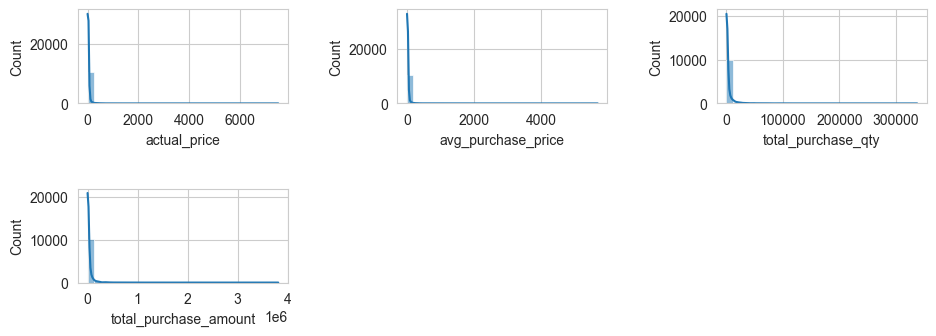

In [103]:
import math
# price related columns
price_cols = ['actual_price','avg_purchase_price','total_purchase_qty','total_purchase_amount']

n_cols = 3
n_rows = math.ceil(len(price_cols)/n_cols)

plt.figure(figsize=(10,2*n_rows))
for i, col in enumerate(price_cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.histplot(df[col], kde=True, bins=30)
   # plt.title(col, fontsize=10)
plt.tight_layout(pad=3)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

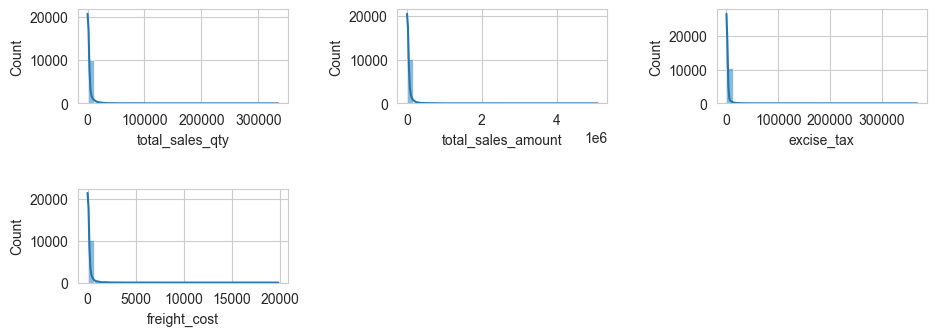

In [104]:
sales_cols = ['total_sales_qty','total_sales_amount','excise_tax','freight_cost']

n_cols = 3
n_rows = math.ceil(len(sales_cols)/n_cols)

plt.figure(figsize=(10,2*n_rows))
for i, col in enumerate(sales_cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.histplot(df[col], kde=True, bins=30)
   # plt.title(col, fontsize=10)
plt.tight_layout(pad=3)
plt.show

In [105]:
df.columns

Index(['vendor_number', 'vendor_name', 'brand', 'description', 'actual_price',
       'avg_purchase_price', 'total_purchase_qty', 'total_sales_qty',
       'total_purchase_amount', 'total_sales_amount', 'excise_tax',
       'freight_cost', 'price_discount', 'gross_profit', 'profit_margin',
       'sell_through_rate'],
      dtype='str')

<function matplotlib.pyplot.show(close=None, block=None)>

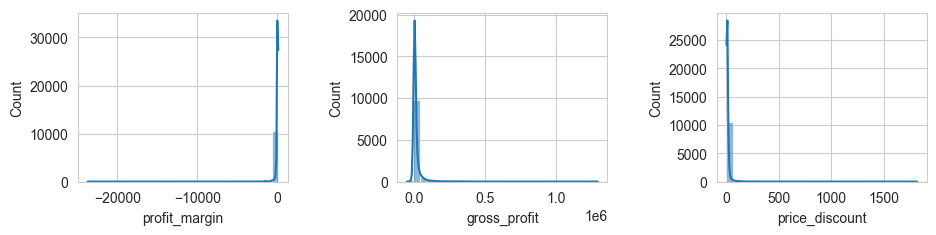

In [106]:
profit_cols = ['profit_margin','gross_profit','price_discount']

n_cols = 3
n_rows = math.ceil(len(profit_cols)/n_cols)

plt.figure(figsize=(10,3*n_rows))
for i, col in enumerate(profit_cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.histplot(df[col], kde=True, bins=30)
   # plt.title(col, fontsize=10)
plt.tight_layout(pad=3)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

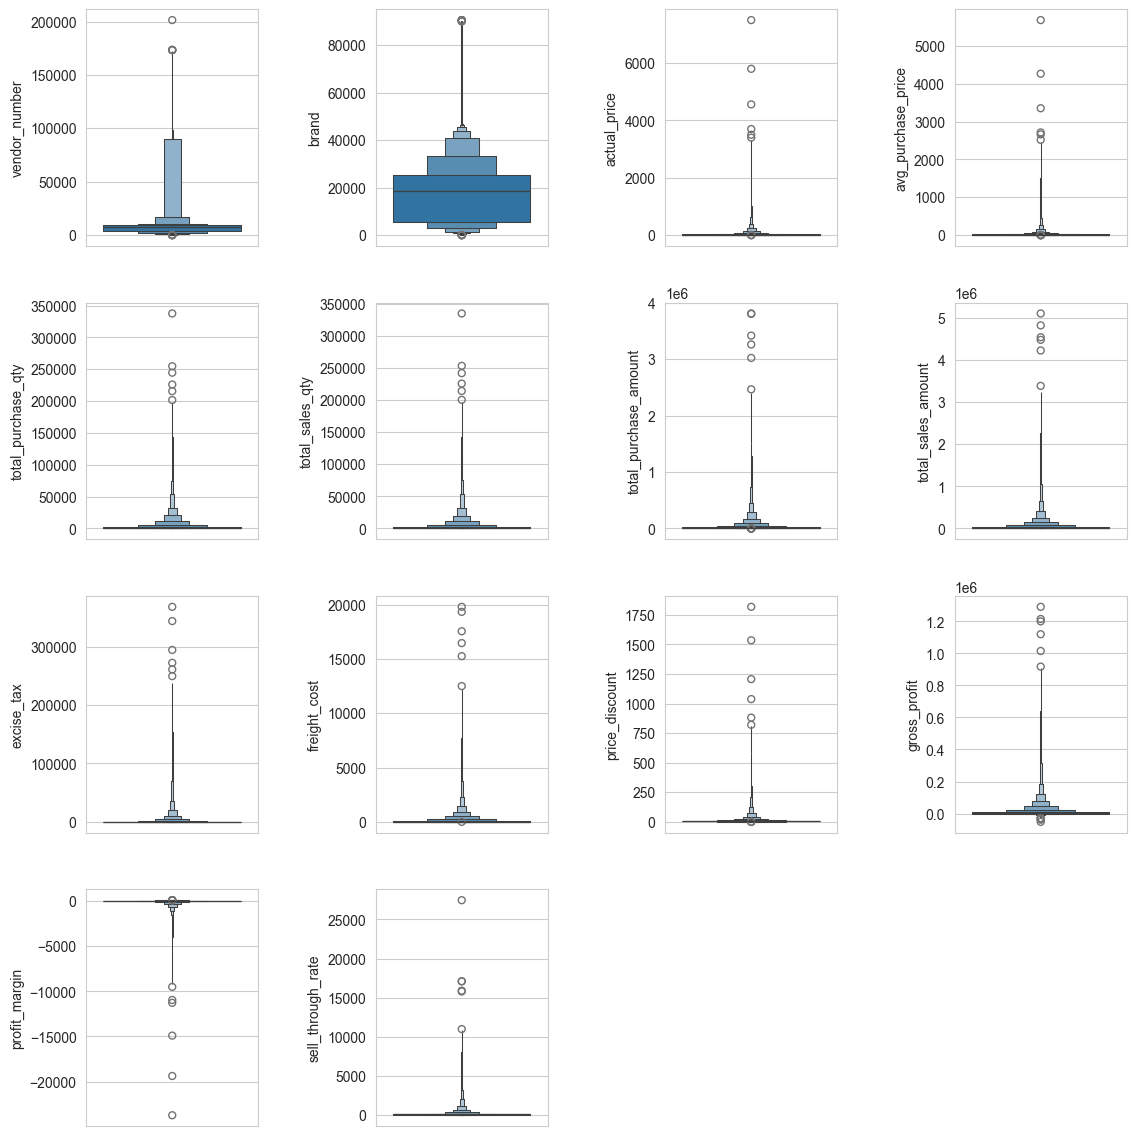

In [107]:
numeric_cols=df.select_dtypes(include=np.number).columns
n_cols = 4
n_rows = math.ceil(len(numeric_cols)/n_cols)

plt.figure(figsize=(12,3*n_rows))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.boxenplot(y=df[col])
   # plt.title(col, fontsize=10)
plt.tight_layout(pad=3)
plt.show

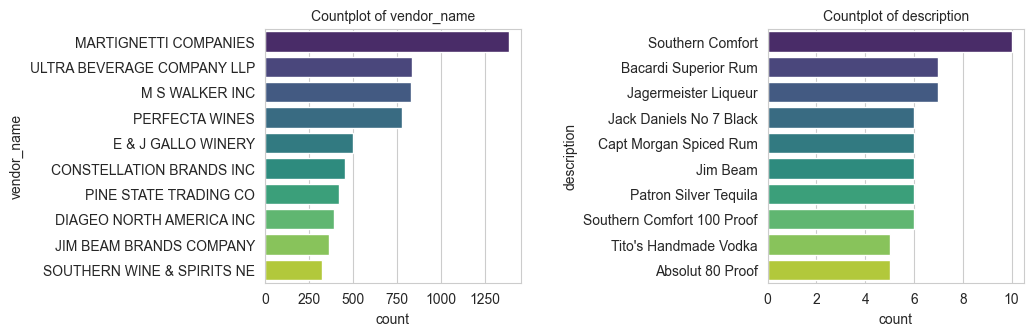

In [108]:
category_cols = ['vendor_name','description']
n_cols = 3
n_rows = math.ceil(len(category_cols)/n_cols)

plt.figure(figsize=(16,4*n_rows))
for i, col in enumerate(category_cols):
    plt.subplot(n_rows,n_cols,i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10], palette='viridis')
    plt.title(f'Countplot of {col}', fontsize=10)
plt.tight_layout(pad=3)
plt.show()

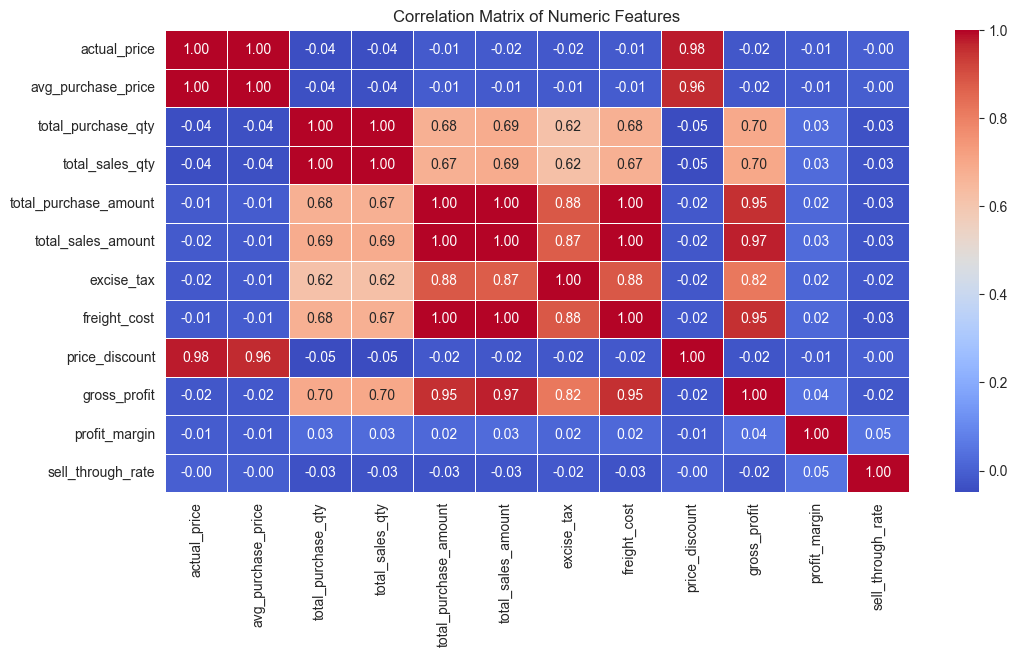

In [109]:
numeric_cols=df.select_dtypes(include=np.number).drop(columns=['vendor_number','brand']).columns
plt.figure(figsize=(12,6))
correlation_matrix = df[numeric_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=12)
plt.show()

Q. Identify the brands that needs promotional or pricing adjustment which exhibit lower sales but higher profit margin ?

In [110]:
df.columns

Index(['vendor_number', 'vendor_name', 'brand', 'description', 'actual_price',
       'avg_purchase_price', 'total_purchase_qty', 'total_sales_qty',
       'total_purchase_amount', 'total_sales_amount', 'excise_tax',
       'freight_cost', 'price_discount', 'gross_profit', 'profit_margin',
       'sell_through_rate'],
      dtype='str')

In [111]:
'''brand performance analysis'''
brand_performance = df.groupby('brand').agg({'total_sales_amount':'sum', 'profit_margin':'mean'}).reset_index()

'''thresh set for low sales and high profit margin'''
low_sales_threshold = df['total_sales_amount'].quantile(0.15)
high_profit_threshold = df['profit_margin'].quantile(0.85)

'''identify target brands'''
target_brands = brand_performance[
    (brand_performance['total_sales_amount'] <= low_sales_threshold) &
    (brand_performance['profit_margin'] >= high_profit_threshold)
]
print("Target Brands for Improvement:")
display(target_brands.sort_values(by='profit_margin', ascending=False))

Target Brands for Improvement:


,brand,total_sales_amount,profit_margin
1448,3065,85.14,99.17
2730,6127,143.28,98.97
10027,41231,279.80,97.67
4921,17172,161.73,97.46
3106,7902,156.42,97.24
...,...,...,...
417,923,90.93,56.36
577,1243,233.82,55.69
9987,40757,215.82,55.24
4944,17282,173.94,54.95


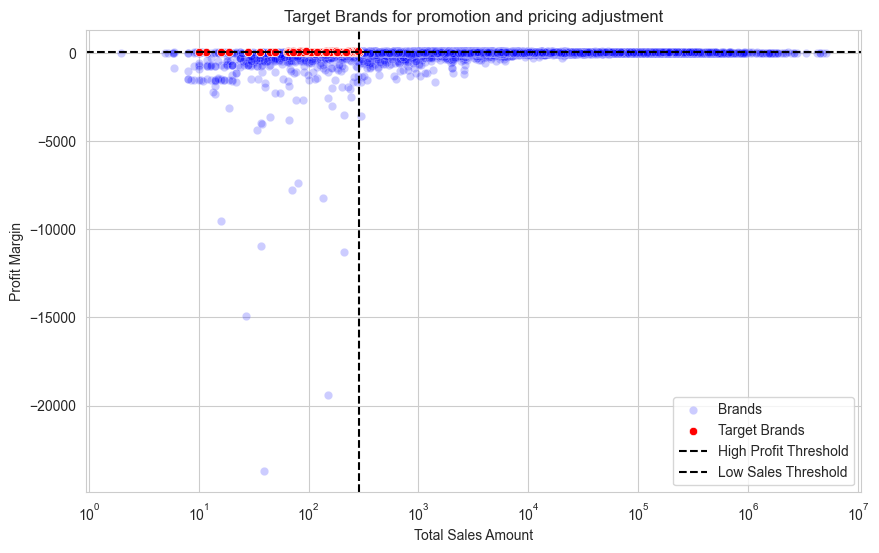

In [112]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=brand_performance, x='total_sales_amount', y='profit_margin', color='blue', label='Brands', alpha=0.2)
sns.scatterplot(data=target_brands, x='total_sales_amount', y='profit_margin', color='red', label='Target Brands')
plt.axhline(y=high_profit_threshold, color='black', linestyle='--', label='High Profit Threshold')
plt.axvline(x=low_sales_threshold, color='black', linestyle='--', label='Low Sales Threshold')
plt.xlabel('Total Sales Amount')
plt.ylabel('Profit Margin')
plt.title('Target Brands for promotion and pricing adjustment')
plt.legend()
plt.grid(True)
plt.xscale('log')
plt.show()

In [113]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "vscode"

non_target = brand_performance[
    ~brand_performance['brand'].isin(target_brands['brand'])
]

fig = px.scatter(
    non_target,
    x='total_sales_amount',
    y='profit_margin',
    hover_name='brand',
    title='Target Brands for Promotion and Pricing Adjustment',
    color_discrete_sequence=['blue']
)

# highlight target brands
fig.add_scatter(
    x=target_brands['total_sales_amount'],
    y=target_brands['profit_margin'],
    mode='markers',   # removed +text
    marker=dict(color='red', size=12),
    name='Target Brands',
    customdata=target_brands['brand'],
    hovertemplate="<b>%{customdata}</b><br>Sales: %{x:,.0f}<br>Profit Margin: %{y:.2f}<extra></extra>"
)

fig.add_hline(y=high_profit_threshold, line_dash="dash", line_color="black")
fig.add_vline(x=low_sales_threshold, line_dash="dash", line_color="black")

fig.update_layout(
    width=1100,
    height=650
)
fig.show()

Q. Which vendor or brand demonstrate the highest sales performance ?

In [114]:
def format_dollar(x):
    if x >= 1e6:
        return f'${x/1e6:.2f}M'
    elif x >= 1e3:
        return f'${x/1e3:.2f}K'
    else:
        return f'${x:.0f}'

In [115]:
top_vendors = df.groupby('vendor_name')['total_sales_amount'].sum().nlargest(10)
top_vendors = top_vendors.apply(format_dollar).sort_values(ascending=False)
top_vendors

vendor_name
DIAGEO NORTH AMERICA INC      $68.74M
MARTIGNETTI COMPANIES         $40.96M
PERNOD RICARD USA             $32.28M
JIM BEAM BRANDS COMPANY       $31.90M
BACARDI USA INC               $25.01M
CONSTELLATION BRANDS INC      $24.47M
E & J GALLO WINERY            $18.55M
BROWN-FORMAN CORP             $18.48M
ULTRA BEVERAGE COMPANY LLP    $17.80M
M S WALKER INC                $15.44M
Name: total_sales_amount, dtype: str

In [116]:
top_brands = df.groupby('description')['total_sales_amount'].sum().nlargest(10)
top_brands = top_brands.apply(format_dollar).sort_values(ascending=False)
top_brands

description
Jack Daniels No 7 Black    $7.96M
Tito's Handmade Vodka      $7.40M
Grey Goose Vodka           $7.21M
Capt Morgan Spiced Rum     $6.36M
Absolut 80 Proof           $6.24M
Jameson Irish Whiskey      $5.72M
Ketel One Vodka            $5.07M
Baileys Irish Cream        $4.15M
Kahlua                     $3.60M
Tanqueray                  $3.46M
Name: total_sales_amount, dtype: str

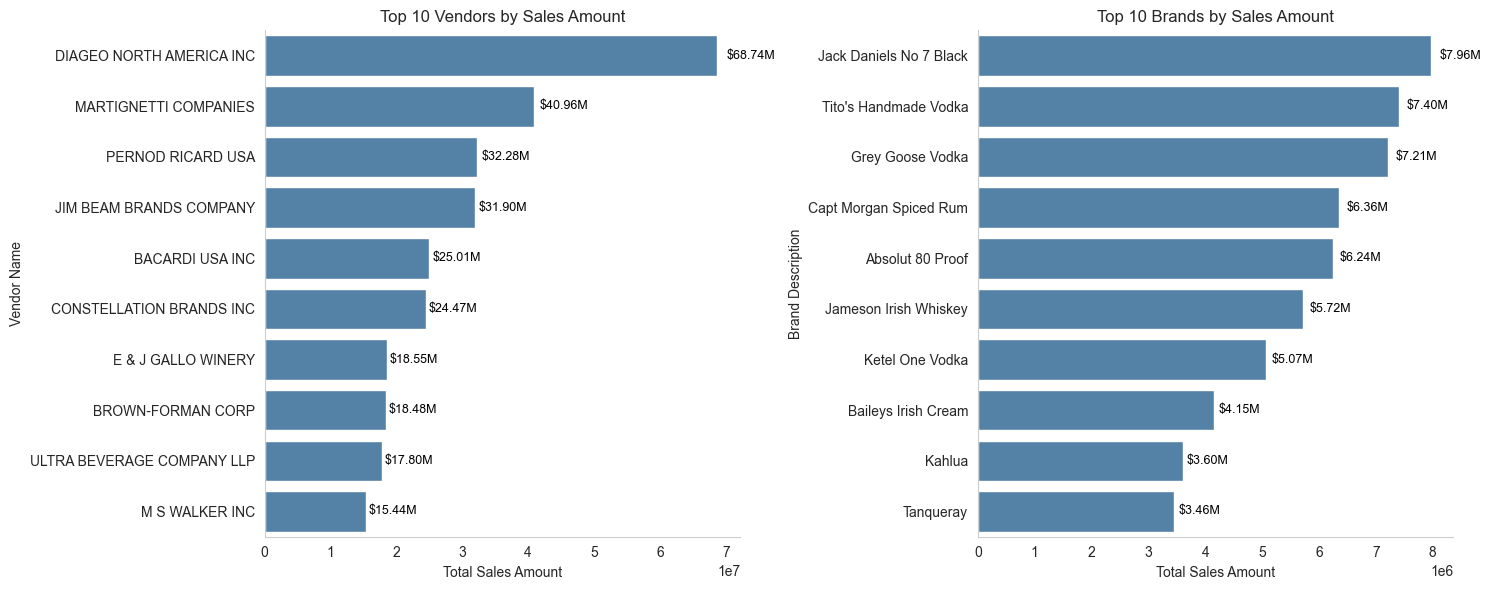

In [175]:
top_vendors = df.groupby('vendor_name')['total_sales_amount'].sum().nlargest(10)

top_brands = df.groupby('description')['total_sales_amount'].sum().nlargest(10)

fig, axes = plt.subplots(1, 2, figsize=(15,6))
# plot for top vendors 
sns.barplot(x=top_vendors.values, y=top_vendors.index.astype(str), color='steelblue', ax=axes[0])
axes[0].set_title('Top 10 Vendors by Sales Amount', fontsize=12)
axes[0].set_xlabel('Total Sales Amount')
axes[0].set_ylabel('Vendor Name')
axes[0].grid(False)
for i, v in enumerate(top_vendors.values):
    axes[0].text(v + (v * 0.02), i, f"${v/1e6:.2f}M", va='center', fontsize=9, ha='left', color='black')

# plot for top brands
sns.barplot(x=top_brands.values, y=top_brands.index.astype(str), color='steelblue', ax=axes[1])
axes[1].set_title('Top 10 Brands by Sales Amount', fontsize=12)         
axes[1].set_xlabel('Total Sales Amount')
axes[1].set_ylabel('Brand Description')
axes[1].grid(False)
for i, v in enumerate(top_brands.values):
    axes[1].text(v + (v * 0.02), i, f"${v/1e6:.2f}M", va='center', fontsize=9, ha='left', color='black')
sns.despine()
plt.tight_layout()
plt.show()

Q. Which vendors contribute the most to the total_purchase_amount ?

In [ ]:
vendor_performance = df.groupby('vendor_name').agg({'total_purchase_amount':'sum','gross_profit':'sum','total_sales_amount':'sum'}).reset_index()
vendor_performance['purchase_contribution'] = vendor_performance['total_purchase_amount']/vendor_performance['total_purchase_amount'].sum() * 100
vendor_performance = vendor_performance.round(2).sort_values(by='purchase_contribution', ascending=False).head(10)

In [135]:
top_vendor = vendor_performance.sort_values(by='purchase_contribution', ascending=False).head(10)
top_vendor['total_purchase_amount'] = top_vendor['total_purchase_amount'].apply(format_dollar)
top_vendor['gross_profit'] = top_vendor['gross_profit'].apply(format_dollar)
top_vendor['total_sales_amount'] = top_vendor['total_sales_amount'].apply(format_dollar)
top_vendor

,vendor_name,total_purchase_amount,gross_profit,total_sales_amount,purchase_contribution
28,DIAGEO NORTH AMERICA INC,$50.96M,$17.78M,$68.74M,15.83
63,MARTIGNETTI COMPANIES,$27.86M,$13.14M,$40.96M,8.66
50,JIM BEAM BRANDS COMPANY,$24.20M,$7.70M,$31.90M,7.52
74,PERNOD RICARD USA,$24.12M,$8.16M,$32.28M,7.49
8,BACARDI USA INC,$17.62M,$7.38M,$25.01M,5.48
23,CONSTELLATION BRANDS INC,$15.57M,$8.90M,$24.47M,4.84
14,BROWN-FORMAN CORP,$13.53M,$4.95M,$18.48M,4.20
114,ULTRA BEVERAGE COMPANY LLP,$13.21M,$4.70M,$17.80M,4.10
33,E & J GALLO WINERY,$12.29M,$6.27M,$18.55M,3.82
59,M S WALKER INC,$10.94M,$4.56M,$15.44M,3.40


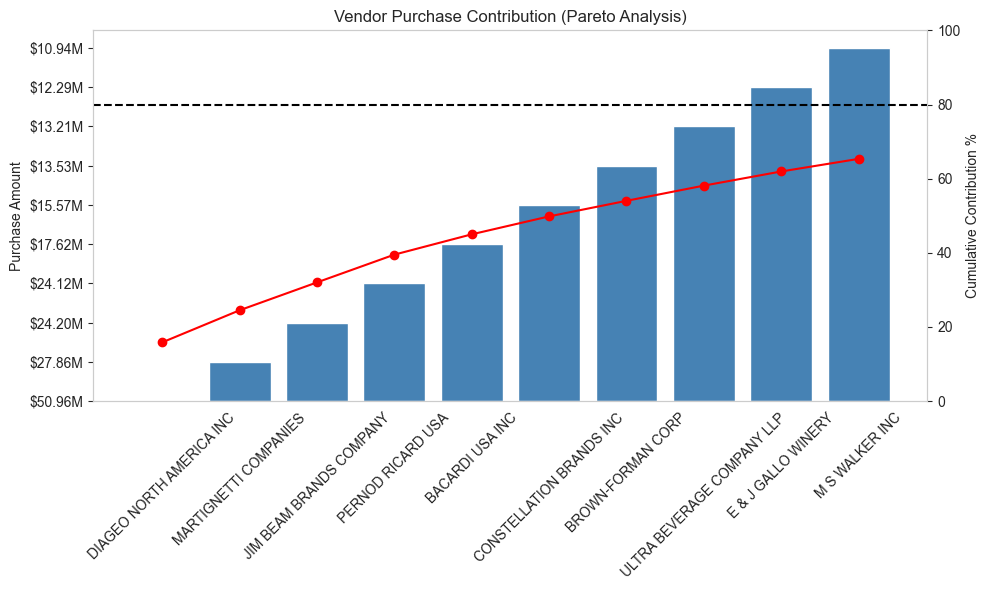

In [176]:
import matplotlib.pyplot as plt
import numpy as np

# use numeric column
top_vendor['cummulative_contribution'] = top_vendor['purchase_contribution'].cumsum()



fig, ax1 = plt.subplots(figsize=(10,6))

# bars
ax1.bar(
    top_vendor['vendor_name'],
    top_vendor['total_purchase_amount'],
    color="steelblue"
)

ax1.set_ylabel("Purchase Amount")
ax1.set_title("Vendor Purchase Contribution (Pareto Analysis)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(False)

# cumulative line
ax2 = ax1.twinx()

ax2.plot(
    top_vendor['vendor_name'],
    top_vendor['cummulative_contribution'],
    color="red",
    marker="o"
)

ax2.set_ylabel("Cumulative Contribution %")
ax2.set_ylim(0,100)
ax2.grid(False)

# 80% line
ax2.axhline(80, color="black", linestyle="--")

plt.tight_layout()
plt.show()

Q. How much of total procurement is dependent on the top vendors ?

In [143]:
print(f'Total purchase contribution of top 10 vendors: {top_vendor['purchase_contribution'].sum()}%')

Total purchase contribution of top 10 vendors: 65.34%


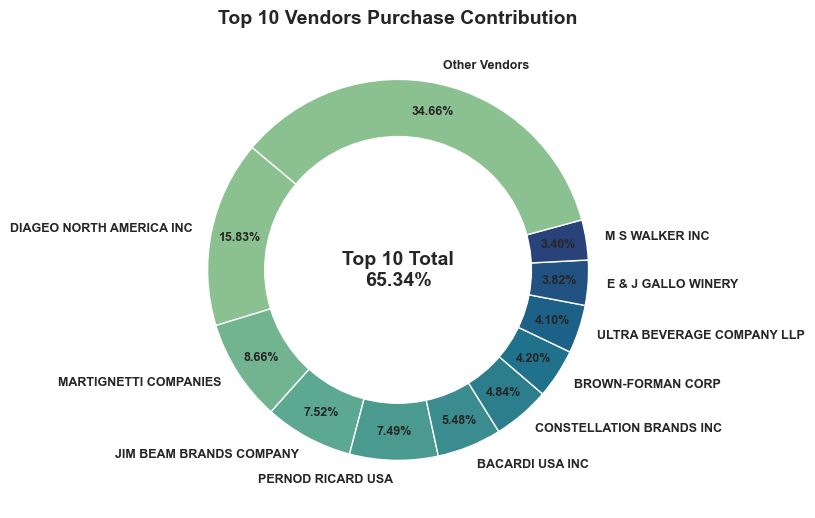

In [186]:
import matplotlib.pyplot as plt

# Top vendors already computed
vendors = list(top_vendor['vendor_name'].values)
purchase_contributions = list(top_vendor['purchase_contribution'].values)

# calculate remaining contribution
total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# append Others
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

colors = sns.color_palette("crest", len(values))

# donut chart
fig, ax = plt.subplots(figsize=(8,8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.2f%%',
    startangle=140,
    pctdistance=0.85,
    colors=colors,
    textprops={'fontsize':9, 'fontweight':'bold'}
)

# donut hole
centre_circle = plt.Circle((0,0),0.70,fc='white')
fig.gca().add_artist(centre_circle)

# center text
plt.text(
    0,0,
    f"Top 10 Total\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendors Purchase Contribution",fontweight='bold',fontsize=14)
plt.tight_layout()
plt.show()

Q. Does purchasing in bulk reduce the unit price and what is the optimal purchase volume for cost saving ?

In [191]:
# create unit price
df['unit_price'] = df['total_purchase_amount'] / df['total_purchase_qty']

# categorize order size
df['order_size'] = pd.qcut(
    df['total_purchase_qty'],
    q=3,
    labels=['Small','Medium','Large']
)

# analyze average unit price
df.groupby('order_size')['unit_price'].mean()

order_size
Small     43.776954
Medium    17.894005
Large     11.308807
Name: unit_price, dtype: float64

In [192]:
df.columns

Index(['vendor_number', 'vendor_name', 'brand', 'description', 'actual_price',
       'avg_purchase_price', 'total_purchase_qty', 'total_sales_qty',
       'total_purchase_amount', 'total_sales_amount', 'excise_tax',
       'freight_cost', 'price_discount', 'gross_profit', 'profit_margin',
       'sell_through_rate', 'unit_price', 'order_size'],
      dtype='str')

Q. Which vendors have low inventory turnover, indicating excess stock and slow-moving products ?

In [219]:
# low sell_through_rate(slr) vendors
low_slr_vendor = df[(df['sell_through_rate'] < 1) & (df['sell_through_rate'] > 0) ].groupby('vendor_name')[['sell_through_rate']].mean().sort_values(by='sell_through_rate').head(10)
low_slr_vendor

,sell_through_rate
vendor_name,
TREASURY WINE ESTATES,0.28
SOUTHERN WINE & SPIRITS NE,0.33
ULTRA BEVERAGE COMPANY LLP,0.57
SOUTHERN GLAZERS W&S OF NE,0.60
VINILANDIA USA,0.68
MARTIGNETTI COMPANIES,0.70
M S WALKER INC,0.88


In [226]:
import numpy as np

vendor_slr = (
    df.groupby('vendor_name')
      .agg(
          total_sales=('total_sales_qty','sum'),
          total_purchase=('total_purchase_qty','sum')
      )
)

# avoid divide-by-zero
vendor_slr['sell_through_rate'] = np.where(
    vendor_slr['total_purchase'] > 0,
    vendor_slr['total_sales'] / vendor_slr['total_purchase'],
    np.nan
)

# inventory risk
vendor_slr['unsold_inventory'] = (
    vendor_slr['total_purchase'] - vendor_slr['total_sales']
)

# optional: remove tiny purchases
vendor_slr = vendor_slr[vendor_slr['total_purchase'] > 50]

# lowest performers
low_slr_vendor = (
    vendor_slr
    .sort_values('sell_through_rate')
    .head(10)
)

low_slr_vendor

,total_sales,total_purchase,sell_through_rate,unsold_inventory
vendor_name,,,,
"IRA GOLDMAN AND WILLIAMS, LLP",42.0,328,0.128049,286.0
HIGHLAND WINE MERCHANTS LLC,82.0,372,0.220430,290.0
UNCORKED,61.0,243,0.251029,182.0
VINEYARD BRANDS LLC,104.0,371,0.280323,267.0
LOYAL DOG WINERY,74.0,240,0.308333,166.0
BLACK COVE BEVERAGES,313.0,919,0.340588,606.0
GILMANTON WINERY & VINEYARD,240.0,516,0.465116,276.0
APPOLO VINEYARDS LLC,108.0,230,0.469565,122.0
STARK BREWING COMPANY,846.0,1212,0.698020,366.0


In [230]:
vendor_stock = (
    df.groupby('vendor_name')
      .agg(
          total_purchase=('total_purchase_qty','sum'),
          total_sales=('total_sales_qty','sum')
      )
)

# dead stock calculation
vendor_stock['dead_stock_qty'] = (
    vendor_stock['total_purchase'] -
    vendor_stock['total_sales']
)

vendor_stock['dead_stock_ratio'] = (
    vendor_stock['dead_stock_qty'] /
    vendor_stock['total_purchase']
)

# 🔴 apply purchase constraint
vendor_stock = vendor_stock[
    vendor_stock['total_purchase'] > 1000
]

# worst vendors
dead_stock_vendor = (
    vendor_stock
    .sort_values('dead_stock_ratio', ascending=False)
    .head(10)
)


dead_stock_vendor.round(2)

,total_purchase,total_sales,dead_stock_qty,dead_stock_ratio
vendor_name,,,,
STARK BREWING COMPANY,1212,846.0,366.0,0.30
Circa Wines,3320,2443.0,877.0,0.26
Dunn Wine Brokers,5448,4063.0,1385.0,0.25
TAMWORTH DISTILLING,1990,1488.0,502.0,0.25
THE IMPORTED GRAPE LLC,2280,1719.0,561.0,0.25
SWEETWATER FARM,1629,1237.0,392.0,0.24
SOUTHERN GLAZERS W&S OF NE,4198,3288.0,910.0,0.22
TALL SHIP DISTILLERY LLC,2236,1786.0,450.0,0.20
PARK STREET IMPORTS LLC,4349,3483.0,866.0,0.20


<Axes: ylabel='vendor_name'>

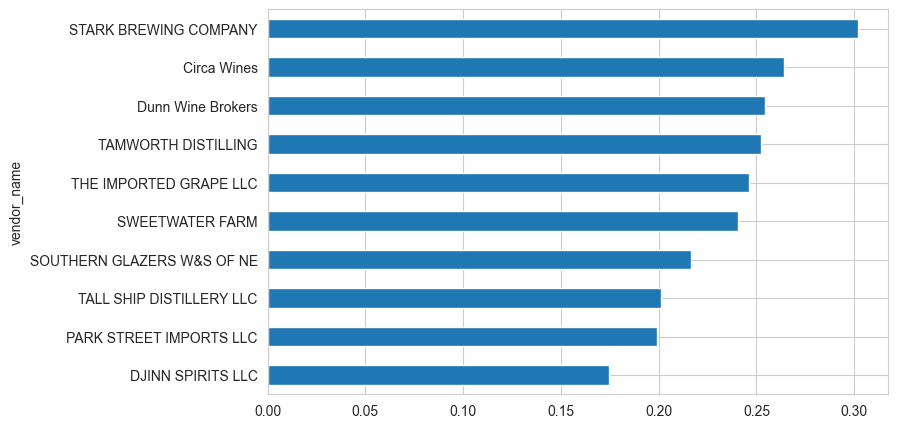

In [231]:
dead_stock_vendor.sort_values('dead_stock_ratio').plot.barh(
    y='dead_stock_ratio',
    figsize=(8,5),
    legend=False
)

In [233]:
df.columns

Index(['vendor_number', 'vendor_name', 'brand', 'description', 'actual_price',
       'avg_purchase_price', 'total_purchase_qty', 'total_sales_qty',
       'total_purchase_amount', 'total_sales_amount', 'excise_tax',
       'freight_cost', 'price_discount', 'gross_profit', 'profit_margin',
       'sell_through_rate', 'unit_price', 'order_size', 'stock_turnover'],
      dtype='str')

Q. How much capital is locked in unsold inventory per vendor and which vendors contributed the most to it ?

In [235]:
df['unsold_inventory'] = (df['total_purchase_qty'] - df['total_sales_qty']) * df['avg_purchase_price']
total_capital_at_risk = df['unsold_inventory'].sum()
print(f"Total Capital at Risk due to Unsold Inventory: ${total_capital_at_risk:,.2f}")

Total Capital at Risk due to Unsold Inventory: $8,750,806.76


In [239]:
ivnentory_risk = df.groupby('vendor_name')[['unsold_inventory']].sum().sort_values(by='unsold_inventory', ascending=False).head(10)
ivnentory_risk

,unsold_inventory
vendor_name,
DIAGEO NORTH AMERICA INC,981589.89
MARTIGNETTI COMPANIES,928987.31
JIM BEAM BRANDS COMPANY,857795.51
ULTRA BEVERAGE COMPANY LLP,780266.12
PERFECTA WINES,571806.73
PERNOD RICARD USA,554740.67
M S WALKER INC,470108.40
WILLIAM GRANT & SONS INC,436492.34
E & J GALLO WINERY,315202.46


<Axes: ylabel='vendor_name'>

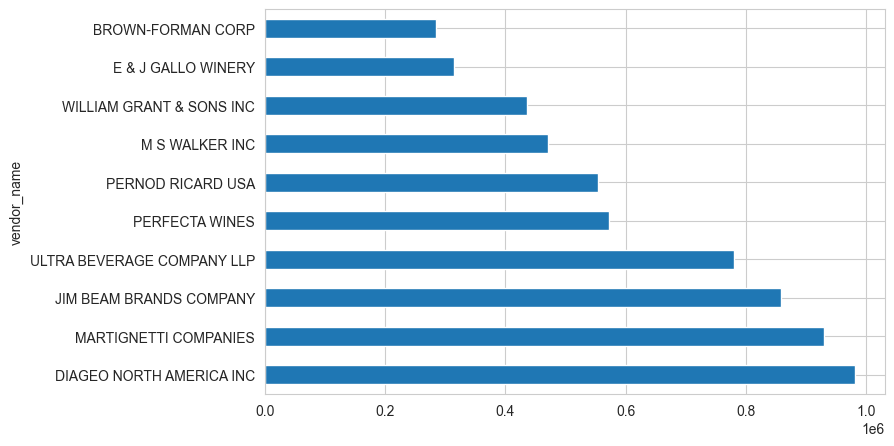

In [240]:
ivnentory_risk.plot.barh(
    figsize=(8,5),
    legend=False
)


Q. What is the distribution of vendors across strategic, risk, growth, and underperforming segments?

In [ ]:
import plotly.express as px
import plotly.io as pio

pio.renderers.default = "vscode"

# vendor aggregation
vendor_perf = (
    df.groupby('vendor_name')
      .agg(
          total_sales=('total_sales_amount','sum'),
          avg_profit_margin=('profit_margin','mean')
      )
      .reset_index()
)

# thresholds
sales_threshold = vendor_perf['total_sales'].median()
margin_threshold = vendor_perf['avg_profit_margin'].median()

# classify vendors
def classify(row):
    if row['total_sales'] >= sales_threshold and row['avg_profit_margin'] >= margin_threshold:
        return "Strategic Vendors"
    elif row['total_sales'] >= sales_threshold and row['avg_profit_margin'] < margin_threshold:
        return "Margin Risk"
    elif row['total_sales'] < sales_threshold and row['avg_profit_margin'] >= margin_threshold:
        return "Growth Opportunity"
    else:
        return "Underperforming"

vendor_perf["vendor_group"] = vendor_perf.apply(classify, axis=1)

vendor_perf["size_scaled"] = np.log1p(vendor_perf["total_sales"])
# interactive scatter
fig = px.scatter(
    vendor_perf,
    x="total_sales",
    y="avg_profit_margin",
    color="vendor_group",
    hover_name="vendor_name",
    size="size_scaled",
    size_max=25,
    color_discrete_map={
        "Strategic Vendors":"green",
        "Margin Risk":"orange",
        "Growth Opportunity":"blue",
        "Underperforming":"red"
    },
    title="Vendor Risk Matrix",
    labels={
        "total_sales":"Total Sales",
        "avg_profit_margin":"Average Profit Margin"
    }
)

# quadrant lines
fig.add_vline(x=sales_threshold, line_dash="dash", line_color="black")
fig.add_hline(y=margin_threshold, line_dash="dash", line_color="black")


# improve layout
fig.update_layout(
    width=1100,
    height=650,
    template="plotly_white"
)

# log scale helps when sales are skewed
fig.update_xaxes(type="log")

fig.show()

In [ ]:
vendor_group_count = (
    vendor_perf.groupby("vendor_group")["vendor_name"]
               .count()
               .reset_index(name="vendor_count")
)
vendor_group_count

,vendor_group,vendor_count
0,Growth Opportunity,26
1,Margin Risk,26
2,Strategic Vendors,34
3,Underperforming,33


Q. What is the average profit margin for top 25% sales vendors vs bottom 25% sales vendors? Are the differences statistically significant?

In [247]:
import numpy as np
from scipy import stats
df = df[df['profit_margin'] > 0]  # filter out zero sales to avoid skewing

# thresholds
top_threshold = df["total_sales_amount"].quantile(0.75)
low_threshold = df["total_sales_amount"].quantile(0.25)

# groups
top_vendors = df[df["total_sales_amount"] >= top_threshold]["profit_margin"].dropna()
low_vendors = df[df["total_sales_amount"] <= low_threshold]["profit_margin"].dropna()

# CI function
def confidence_interval(data, confidence=0.95):
    
    data = np.array(data)
    
    mean_val = np.mean(data)
    
    # standard error
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))
    
    # t critical value
    t_critical = stats.t.ppf((1 + confidence) / 2, df=len(data) - 1)
    
    # margin of error
    margin_of_error = t_critical * std_err
    
    lower = mean_val - margin_of_error
    upper = mean_val + margin_of_error
    
    return mean_val, lower, upper
# compute CI
top_ci = confidence_interval(top_vendors)
low_ci = confidence_interval(low_vendors)

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


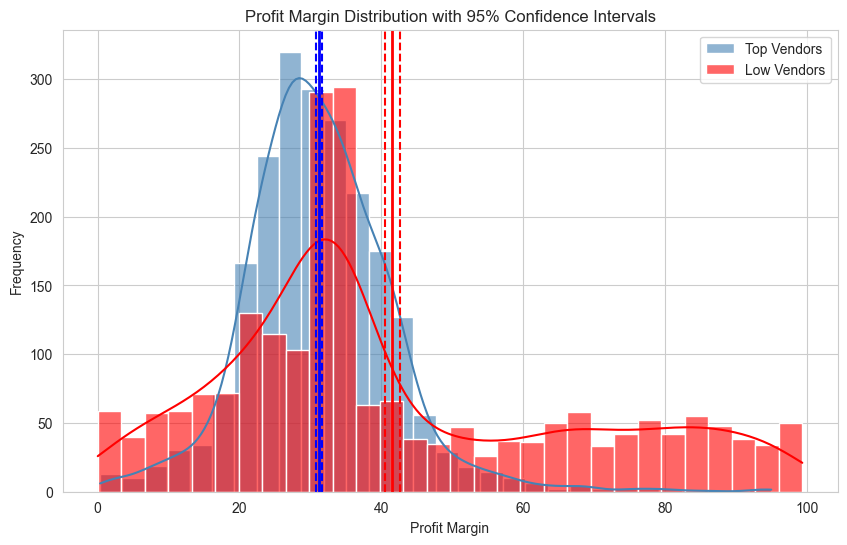

In [251]:
# compute CI
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

plt.figure(figsize=(10,6))

# Top vendors distribution
sns.histplot(
    top_vendors,
    kde=True,
    color="steelblue",
    bins=30,
    alpha=0.6,
    label="Top Vendors"
)

# Low vendors distribution
sns.histplot(
    low_vendors,
    kde=True,
    color="red",
    bins=30,
    alpha=0.6,
    label="Low Vendors"
)

# Top CI lines
plt.axvline(top_mean, color="blue", linestyle="-", linewidth=2)
plt.axvline(top_lower, color="blue", linestyle="--")
plt.axvline(top_upper, color="blue", linestyle="--")

# Low CI lines
plt.axvline(low_mean, color="red", linestyle="-", linewidth=2)
plt.axvline(low_lower, color="red", linestyle="--")
plt.axvline(low_upper, color="red", linestyle="--")

plt.title("Profit Margin Distribution with 95% Confidence Intervals")
plt.xlabel("Profit Margin")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [283]:
vendor_perf

,vendor_name,total_sales,avg_profit_margin,vendor_group,size_scaled
0,ADAMBA IMPORTS INTL INC,704.53,36.670000,Growth Opportunity,6.558949
1,ALISA CARR BEVERAGES,104470.94,75.525833,Growth Opportunity,11.556674
2,ALTAMAR BRANDS LLC,15706.81,24.005000,Underperforming,9.661913
3,AMERICAN SPIRITS EXCHANGE,1511.16,38.190000,Growth Opportunity,7.321294
4,AMERICAN VINTAGE BEVERAGE,139603.53,24.970000,Underperforming,11.846569
...,...,...,...,...,...
114,WEIN BAUER INC,56217.13,25.646000,Underperforming,10.936995
115,WESTERN SPIRITS BEVERAGE CO,405254.83,37.143333,Strategic Vendors,12.912274
116,WILLIAM GRANT & SONS INC,7569876.20,31.172192,Margin Risk,15.839687
117,WINE GROUP INC,8304043.28,33.854880,Margin Risk,15.932253


# Test the profit margin difference between th vendor groups 

To test profit margin differences between vendor groups, use ANOVA because you have more than two groups:

Groups:

    Strategic Vendors

    Margin Risk

    Growth Opportunity

    Underperforming

    Define Hypothesis

H0: Mean profit margin is equal across all vendor groups

H1: At least one vendor group has a different mean profit margin

In [284]:
from scipy.stats import f_oneway

strategic = vendor_perf[vendor_perf["vendor_group"]=="Strategic Vendors"]["avg_profit_margin"]
margin_risk = vendor_perf[vendor_perf["vendor_group"]=="Margin Risk"]["avg_profit_margin"]
growth = vendor_perf[vendor_perf["vendor_group"]=="Growth Opportunity"]["avg_profit_margin"]
underperform = vendor_perf[vendor_perf["vendor_group"]=="Underperforming"]["avg_profit_margin"]

anova_result = f_oneway(strategic, margin_risk, growth, underperform)

print("F-statistic:", anova_result.statistic)
print("p-value:", anova_result.pvalue)

F-statistic: 49.65472671055262
p-value: 1.1614485732274548e-20


ANOVA results indicate a significant difference in profit margins across vendor groups
(F = 49.65, p < 0.001). 

Strategic vendors generate substantially higher margins,
while underperforming vendors show significantly lower profitability.

This confirms that the vendor segmentation reflects real differences in vendor performance.

# Test sales vs margin correlation

H0: Sales and profit margin are not correlated

H1: Sales and profit margin are correlated

In [285]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    vendor_perf["total_sales"],
    vendor_perf["avg_profit_margin"]
)

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: -0.016980187789324443
p-value: 0.8545704766659837


Correlation analysis between vendor sales and profit margin shows no
significant relationship (r = -0.017, p = 0.855), indicating that higher
sales volumes do not systematically lead to lower or higher margins.

Vendor profitability appears to be influenced by factors other than sales volume.

# Test strategic vendors generate significantly higher profit margins than underperforming vendors?

H0: Mean profit margin of Strategic Vendors = Underperforming Vendors

H1: Strategic Vendors have higher profit margins

In [286]:
from scipy.stats import ttest_ind

strategic = vendor_perf[
    vendor_perf["vendor_group"]=="Strategic Vendors"
]["avg_profit_margin"]

underperform = vendor_perf[
    vendor_perf["vendor_group"]=="Underperforming"
]["avg_profit_margin"]

t_stat, p_value = ttest_ind(strategic, underperform, equal_var=False)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 10.423106109243324
p-value: 9.81779424563267e-15


t-test shows a statistically significant difference in profit margins
between Strategic Vendors and Underperforming Vendors (t = 10.42, p < 0.001).

Strategic vendors consistently generate higher profitability,
validating the segmentation derived from the Vendor Risk Matrix.